[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset Shape: (3448, 2)

Training Samples: 2756
Testing Samples: 689

Calculating TF-IDF Matrices...

Evaluating Model with Cross-Validation...

Best Alpha: 0.1
Best Cross Validation Accuracy: 79.54%

Training Accuracy: 94.96%
Testing Accuracy: 81.42%


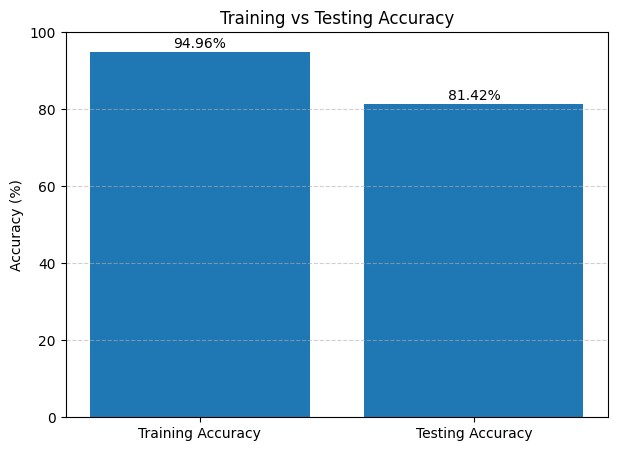

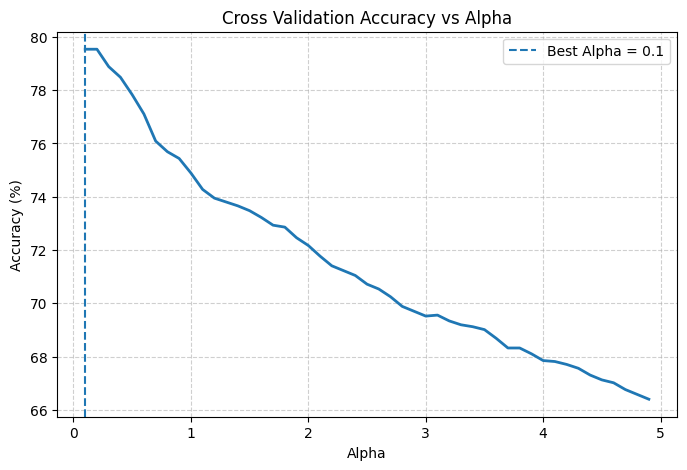

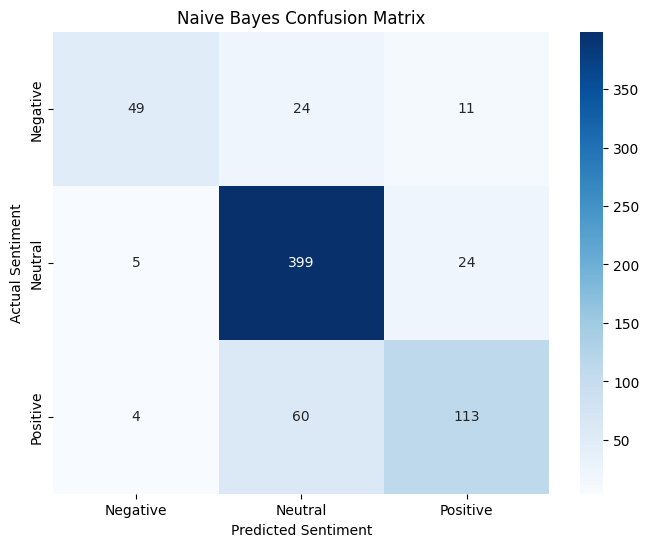


Classification Report:

              precision    recall  f1-score   support

    Negative       0.84      0.58      0.69        84
     Neutral       0.83      0.93      0.88       428
    Positive       0.76      0.64      0.70       177

    accuracy                           0.81       689
   macro avg       0.81      0.72      0.75       689
weighted avg       0.81      0.81      0.81       689



In [1]:
# ============================================================
# NAIVE BAYES - FINANCIAL PHRASEBANK SENTIMENT ANALYSIS
# ============================================================

# !pip install pandas numpy nltk matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# DOWNLOAD STOPWORDS
# ============================================================

nltk.download('stopwords')

from nltk.corpus import stopwords

# ============================================================
# 1. LOAD FINANCIAL PHRASEBANK DATASET
# ============================================================

texts = []
labels = []

with open(
    'Sentences_75Agree.txt',
    'r',
    encoding='latin1'
) as file:

    lines = file.readlines()

    for line in lines:

        line = line.strip()

        if len(line) == 0:
            continue

        # Split text and sentiment
        text, sentiment = line.rsplit('@', 1)

        texts.append(text.strip())
        labels.append(sentiment.strip())

# Create dataframe
data = pd.DataFrame({
    'Text': texts,
    'Sentiment': labels
})

# Remove duplicates
data.drop_duplicates(subset=['Text'], inplace=True)

print("Dataset Shape:", data.shape)

# ============================================================
# 2. LABEL ENCODING
# ============================================================

label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

data['Sentiment'] = data['Sentiment'].map(label_mapping)

# ============================================================
# 3. PREPROCESSING
# ============================================================

def preprocess_tweets(data):

    data['Text_Cleaned'] = data['Text'].astype(str).str.lower()

    # Remove URLs
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'http\\S+|www\\S+|https\\S+',
        '',
        regex=True
    )

    # Remove mentions
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'@[A-Za-z0-9_]+',
        '',
        regex=True
    )

    # Remove hashtags
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'#[A-Za-z0-9_]+',
        '',
        regex=True
    )

    # Remove special characters
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'[^a-zA-Z0-9\\s]',
        ' ',
        regex=True
    )

    # Remove extra spaces
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'\\s+',
        ' ',
        regex=True
    )

    data['Text_Cleaned'] = data['Text_Cleaned'].str.strip()

    return data

data = preprocess_tweets(data)

# ============================================================
# 4. REMOVE STOPWORDS
# ============================================================

StopWords = set([
    s.replace("'", '')
    for s in stopwords.words('english')
    if s not in [
        'not',
        'up',
        'down',
        'above',
        'below',
        'under',
        'over'
    ]
])

data['Text_Processed'] = data['Text_Cleaned'].apply(
    lambda s: " ".join([
        word for word in s.split()
        if word not in StopWords
    ])
)

data['Text_Processed'] = data['Text_Processed'].str.strip()

# Remove short rows
data = data[data['Text_Processed'].str.len() > 5]

# ============================================================
# 5. TRAIN TEST SPLIT
# ============================================================

X = data['Text_Processed'].values
y = data['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ============================================================
# 6. TF-IDF VECTORIZATION
# ============================================================

print("\nCalculating TF-IDF Matrices...")

tf_idf = TfidfVectorizer(
    ngram_range=(1, 3),
    binary=True,
    smooth_idf=False,
    max_features=10000,
    min_df=2
)

X_train_tfidf = tf_idf.fit_transform(X_train)
X_test_tfidf = tf_idf.transform(X_test)

# ============================================================
# 7. CROSS VALIDATION FOR BEST ALPHA
# ============================================================

print("\nEvaluating Model with Cross-Validation...")

def get_accuracy_cv(model):

    kf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        scoring='accuracy',
        cv=kf
    )

    return scores.mean()

alphas = np.arange(0.1, 5, 0.1)

models = [
    MultinomialNB(alpha=i)
    for i in alphas
]

cv_scores = []

for model in models:

    score = get_accuracy_cv(model)

    cv_scores.append(score)

cv_scores = np.array(cv_scores)

best_alpha = round(
    alphas[cv_scores.argmax()],
    2
)

best_cv_score = cv_scores.max() * 100

print(
    f'\nBest Alpha: {best_alpha}'
)

print(
    f'Best Cross Validation Accuracy: {best_cv_score:.2f}%'
)

# ============================================================
# 8. FINAL MODEL TRAINING
# ============================================================

best_model = MultinomialNB(
    alpha=best_alpha
)

best_model.fit(
    X_train_tfidf,
    y_train
)

# ============================================================
# 9. PREDICTIONS
# ============================================================

train_preds = best_model.predict(
    X_train_tfidf
)

test_preds = best_model.predict(
    X_test_tfidf
)

train_accuracy = accuracy_score(
    y_train,
    train_preds
) * 100

test_accuracy = accuracy_score(
    y_test,
    test_preds
) * 100

print(
    f'\nTraining Accuracy: {train_accuracy:.2f}%'
)

print(
    f'Testing Accuracy: {test_accuracy:.2f}%'
)

# ============================================================
# 10. TRAINING VS TESTING ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['Training Accuracy', 'Testing Accuracy'],
    [train_accuracy, test_accuracy]
)

plt.title('Training vs Testing Accuracy')

plt.ylabel('Accuracy (%)')

plt.ylim(0, 100)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.2f}%',
        ha='center'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.show()

# ============================================================
# 11. ALPHA VS CV ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    alphas,
    cv_scores * 100,
    linewidth=2
)

plt.axvline(
    x=best_alpha,
    linestyle='--',
    label=f'Best Alpha = {best_alpha}'
)

plt.title(
    'Cross Validation Accuracy vs Alpha'
)

plt.xlabel('Alpha')

plt.ylabel('Accuracy (%)')

plt.legend()

plt.grid(
    linestyle='--',
    alpha=0.6
)

plt.show()

# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_preds
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ],
    yticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
)

plt.title('Naive Bayes Confusion Matrix')

plt.xlabel('Predicted Sentiment')

plt.ylabel('Actual Sentiment')

plt.show()

# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_preds,
        target_names=[
            'Negative',
            'Neutral',
            'Positive'
        ]
    )
)